In [ ]:
import pandas as pd
from pathlib import Path
import os

def select_scenario() -> Path:
    # Get all folder names from the logs folder
    logs_folder = Path(os.path.abspath('')) / 'logs'
    scenarios = [folder for folder in logs_folder.iterdir() if folder.is_dir()]
    print('Select a scenario:')
    for i, folder in enumerate(scenarios):
        print(f"[{i}]: {folder.name}")
    print("Your selection: ")
    selection = int(input())
    return scenarios[selection]

scenario_folder = select_scenario()

node_pos_df = pd.read_csv(scenario_folder / 'course_change.csv', delimiter=';', names=["Time","Context","Type","ID","x","y","z"], index_col=False)
node_pos_df

Select a scenario:
[0]: soil
Your selection: 


,Time,Context,Type,ID,x,y,z
0,0,/NodeList/200/$ns3::MobilityModel/CourseChange,AP,200,6.0,6.0,2.0
1,0,/NodeList/0/$ns3::MobilityModel/CourseChange,STA,0,0.4,0.4,-0.3
2,0,/NodeList/1/$ns3::MobilityModel/CourseChange,STA,1,1.2,0.4,-0.3
3,0,/NodeList/2/$ns3::MobilityModel/CourseChange,STA,2,2.0,0.4,-0.3
4,0,/NodeList/3/$ns3::MobilityModel/CourseChange,STA,3,2.8,0.4,-0.3
...,...,...,...,...,...,...,...
198,0,/NodeList/197/$ns3::MobilityModel/CourseChange,STA,197,2.0,10.8,-0.3
199,0,/NodeList/198/$ns3::MobilityModel/CourseChange,STA,198,2.8,10.8,-0.3
200,0,/NodeList/199/$ns3::MobilityModel/CourseChange,STA,199,3.6,10.8,-0.3
201,0,/NodeList/200/$ns3::MobilityModel/CourseChange,STA,200,6.0,6.0,2.0


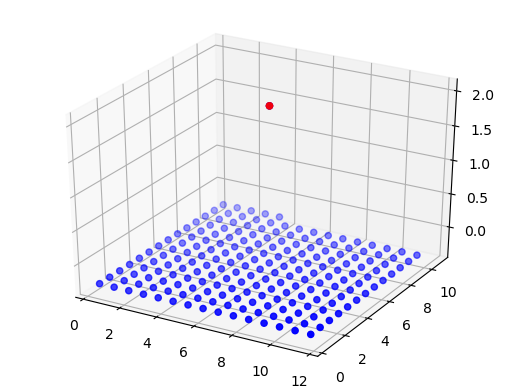

In [28]:
# Plot a 3D graph using the x, y, z coordinates. Color the nodes based on type.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Map 'Type' to colors
color_map = {'AP': 'red', 'STA': 'blue'}
colors = node_pos_df['Type'].map(color_map)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(node_pos_df['x'], node_pos_df['y'], node_pos_df['z'], c=colors)
plt.show()